In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score
import pickle

## Dataset Loading

In [2]:
df = pd.read_csv('student_lifestyle_dataset.csv')

In [3]:
df.head(5)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


In [13]:
encoded_df = df
encoded_df['Stress_Level'] = df['Stress_Level'].map({'Low' : 0, 'Moderate' : 1, 'High' : 2})

In [7]:
df.drop('Stress_Level', axis = 1, inplace = True)

In [14]:
encoded_df.drop('Student_ID', axis = 1, inplace = True)
encoded_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Study_Hours_Per_Day              2000 non-null   float64
 1   Extracurricular_Hours_Per_Day    2000 non-null   float64
 2   Sleep_Hours_Per_Day              2000 non-null   float64
 3   Social_Hours_Per_Day             2000 non-null   float64
 4   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 5   GPA                              2000 non-null   float64
 6   Stress_Level                     2000 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 109.5 KB


In [15]:
encoded_df.describe()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960,1.366000
std,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674,0.727536
min,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000,0.000000
25%,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000,1.000000
50%,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000,2.000000
75%,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000,2.000000
max,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000,2.000000


In [8]:
1.423888/7.475800 	* 100  # coefficient of Variation

19.046630460954013

In [16]:
corr = encoded_df.corr()
corr.GPA.sort_values(ascending = False)

GPA                                1.000000
Study_Hours_Per_Day                0.734468
Stress_Level                       0.550395
Sleep_Hours_Per_Day               -0.004278
Extracurricular_Hours_Per_Day     -0.032174
Social_Hours_Per_Day              -0.085677
Physical_Activity_Hours_Per_Day   -0.341152
Name: GPA, dtype: float64

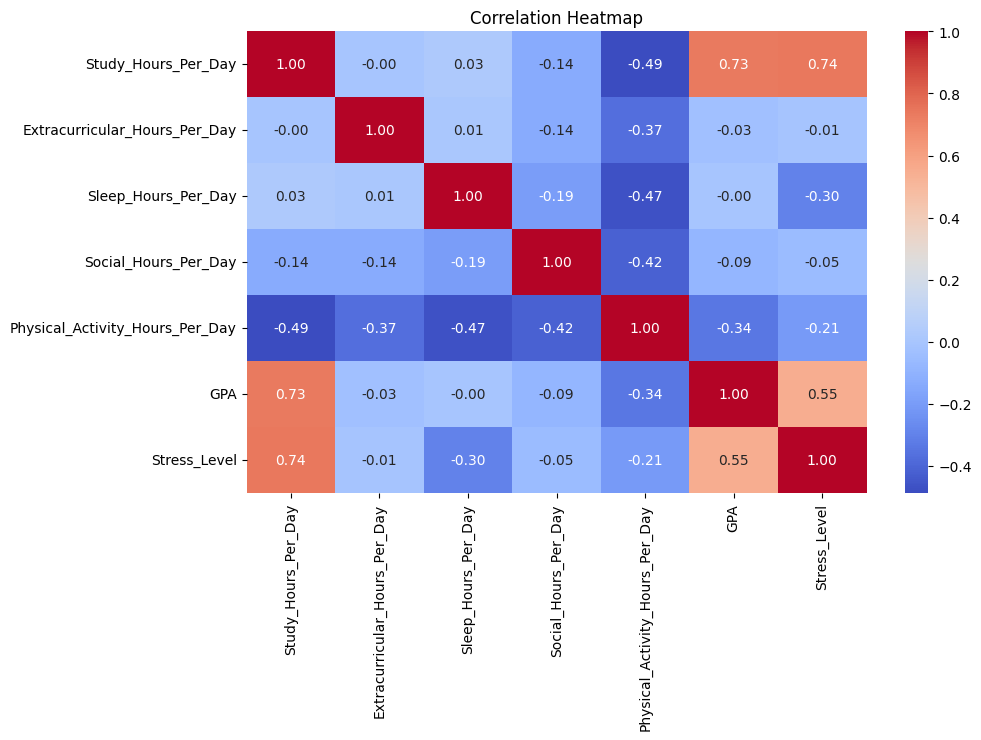

In [17]:
plt.figure(figsize = (10,6))
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
X = encoded_df.drop( 'GPA', axis = 1)
y = encoded_df.GPA

In [218]:
X_train, X_test, y_train, y_test = train_test_split(X,y, shuffle = True, test_size = 0.2)

In [7]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)



NameError: name 'scaler' is not defined

In [220]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
model.score(X_test_scaled, y_test)

0.5696126475181884

In [170]:
print(model.coef_)
print(model.intercept_)

[ 0.1867837  -0.02813782 -0.03417088 -0.03182324 -0.05117357  0.00773573]
3.11410625


In [227]:
y_pred = model.predict(X_test_scaled)

In [224]:
x = np.array([6.9,3.8,8.7,2.8,1.8, 0]).reshape(1,-1)
scaled = scaler.fit_transform(x)

In [225]:
model.predict(scaled)

array([3.11844375])

In [228]:
r2_score(y_test, y_pred)

0.5696126475181884

In [175]:
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error

In [177]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mae
r2

C:\Users\us\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


-6.110588725696098

In [21]:
 mae / X.Study_Hours_Per_Day.mean() * 100

np.float64(2.2740046294879903)

In [29]:
cv_score = cross_val_score(LinearRegression(), X, y, scoring = 'r2', cv = 10, n_jobs = -1)

In [30]:
cv_score

array([0.58326418, 0.54623977, 0.50976378, 0.52601162, 0.50400927,
       0.48656307, 0.56586044, 0.54032991, 0.54019653, 0.55051121])

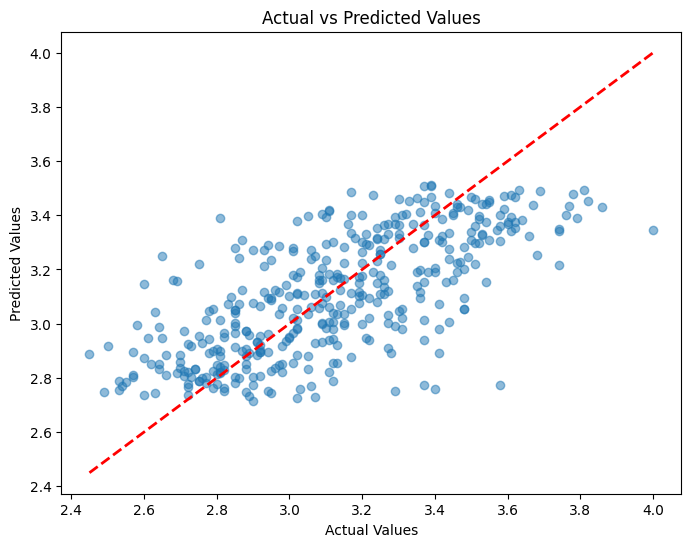

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

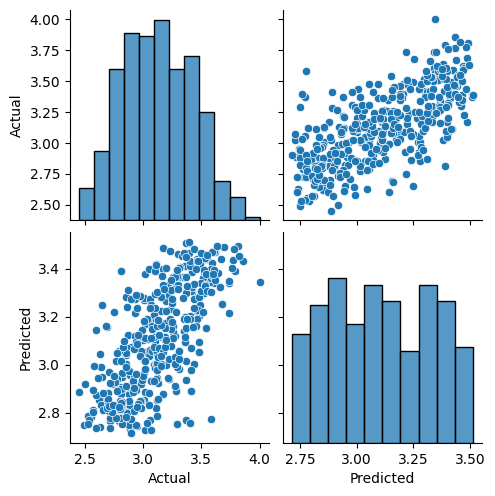

In [32]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Residuals': y_test - y_pred
})

# Pair plot
sns.pairplot(results[['Actual', 'Predicted']])
plt.show()

In [27]:
d = np.array([8.8,1.0,7,1,5]).reshape(1,-1)
model.predict(d)

C:\Users\us\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.35804395])

In [28]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
0,1,6.9,3.8,8.7,2.8,1.8,2.99
1,2,5.3,3.5,8.0,4.2,3.0,2.75
2,3,5.1,3.9,9.2,1.2,4.6,2.67
3,4,6.5,2.1,7.2,1.7,6.5,2.88
4,5,8.1,0.6,6.5,2.2,6.6,3.51


In [30]:
with open (r"C:\Users\us\Desktop\Students_Marks_predictor\model_pickel", 'wb') as f:
    pickle.dump(model,f)

In [31]:
with open(r"C:\Users\us\Desktop\Students_Marks_predictor\model_pickel", 'rb') as f:
    mp = pickle.load(f)

In [32]:
mp.predict(d)

C:\Users\us\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.35804395])

In [36]:
from sklearn.neighbors import KNeighborsRegressor

In [101]:
model2 = KNeighborsRegressor(n_neighbors = 20)

In [102]:
model2.fit(X_train_scaled, y_train)

,n_neighbors,20
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [103]:
y_pred = model2.predict(X_test_scaled)

In [104]:
r2_score(y_test, y_pred)

0.46106113074655797

In [150]:
from sklearn.tree import DecisionTreeRegressor

In [185]:
cv = cross_val_score(LinearRegression(), X_scaled, y, cv = 10, n_jobs = -1)

In [187]:
cv

array([0.58326418, 0.54623977, 0.50976378, 0.52601162, 0.50400927,
       0.48656307, 0.56586044, 0.54032991, 0.54019653, 0.55051121])

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [229]:
with open('model_pickle', 'wb') as f:
    pickle.dump(model,)    


TypeError: dump() missing required argument 'file' (pos 2)

In [22]:
with open('model_pickle', 'rb') as f:
    model = pickle.load(f)
x = np.array([8.0, 4.0, 8.0, 2.0, 0.0, 1]).reshape(1, -1)
scaled_x = scaler.fit_transform(x)
model.predict(scaled_x)
    

array([3.11844375])